# v1/v2 (ALLOW/BLOCK) 데이터 EDA (TYPE별)

참고: `services/ai/train/EDA/eda_chan.ipynb` 형식을 따라가되,
이번 데이터는 아래 3그룹을 TYPE(DETAIL/CAPTCHA/BOOKING)별로 반복 분석합니다.

- v1_ALLOW
- v2_ALLOW
- v2_BLOCK (macro)


In [1]:
import json
from pathlib import Path
from typing import Any, Dict, List, Tuple

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt
import seaborn as sns
import platform

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


In [2]:
# 노트북 세팅 (eda_chan.ipynb 스타일)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 1200)
sns.set_style("whitegrid")

# 한글 폰트 적용(Windows: Malgun Gothic)
system = platform.system()
if system == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
    plt.rcParams["axes.unicode_minus"] = False
    print("폰트: Malgun Gothic")


폰트: Malgun Gothic


## 1. 데이터 준비

이 노트북은 이미 전처리로 만들어진 폴더 구조를 그대로 사용합니다.

가정하는 폴더 구조(대소문자 상관없이 인식):
- `<V1_DIR>/<type>/<label>/trial_*.json`
- `<V2_DIR>/<type>/<label>/trial_*.json`

예)
- `.../data_0514_1800_v2/detail/block/trial_00001.json`


In [3]:
# 데이터 경로 (요청한 경로)
V1_DIR = Path(r"C:\\Users\\SSAFY\\Desktop\\ws\\free\\develop-ai\\S14P31A203\\services\\ai\\data\\data_0514_1800_v1")
V2_DIR = Path(r"C:\\Users\\SSAFY\\Desktop\\ws\\free\\develop-ai\\S14P31A203\\services\\ai\\data\\data_0514_1800_v2")

# feature 설정
FEATURE_CONFIG_PATH = Path(r"C:\Users\SSAFY\Desktop\ws\free\develop-ai\S14P31A203\services\ai\configs\feature_config.yaml")
FEATURE_LIST_KEY = "input_features_chan"  # 필요하면 input_features_chan_10 등으로 변경

# 분석할 TYPE
TYPES = ["DETAIL", "CAPTCHA", "BOOKING"]

# 결측률 기준(표/리스트 출력용)
MISSING_DROP_THRESHOLD = 0.10


In [4]:
feature_config = yaml.safe_load(FEATURE_CONFIG_PATH.read_text(encoding="utf-8"))

FEATURE_GROUPS = feature_config.get("groups", {})
FEATURE_NAME_KR = feature_config.get("names_ko", {})
EXCLUDE_COL = feature_config.get("exclude", [])

FEATURES = list(feature_config.get(FEATURE_LIST_KEY, []))
print("FEATURE_LIST_KEY:", FEATURE_LIST_KEY)
print("FEATURES:", len(FEATURES))
FEATURES[:10]

FEATURE_LIST_KEY: input_features_chan
FEATURES: 30


['time_to_first_click_ms',
 'time_from_element_visible_to_click_ms',
 'time_from_element_clickable_to_click_ms',
 'click_sequence_consistency_score',
 'click_position_repeat_rate',
 'double_click_rate',
 'misclick_rate',
 'reclick_rate',
 'pre_click_mousemove_count',
 'pre_click_hover_time_ms']

### 1-1. trial 로더

- 폴더명이 소문자여도 type/label을 자동 정규화해서 `DETAIL/CAPTCHA/BOOKING`, `ALLOW/BLOCK`으로 맞춥니다.
- metrics 우선, 없으면 features에서 값을 읽습니다.


In [5]:
JsonRecord = Dict[str, Any]


def _norm_type(name: str) -> str:
    u = (name or "").strip().upper()
    for token in ("DETAIL", "CAPTCHA", "BOOKING"):
        if token == u or token in u:
            return token
    return (name or "").strip()


def _norm_label(name: str) -> str:
    t = (name or "").strip().lower()
    if t in {"allow", "human"}:
        return "ALLOW"
    if t in {"block", "macro"}:
        return "BLOCK"
    return (name or "").strip().upper()


def _resolve_metrics(record: JsonRecord) -> Dict[str, Any]:
    metrics = record.get("metrics")
    if isinstance(metrics, dict):
        return metrics
    features = record.get("features")
    if isinstance(features, dict):
        return features
    return {}


def iter_trials(root: Path) -> List[Tuple[Path, str, str]]:
    out: List[Tuple[Path, str, str]] = []
    if not root.exists():
        return out

    for p in sorted(root.glob("*/*/trial_*.json")):
        if not p.is_file():
            continue
        label_dir = p.parent
        type_dir = label_dir.parent
        out.append((p, _norm_type(type_dir.name), _norm_label(label_dir.name)))
    return out


def build_df(root: Path, *, version: str, features: List[str]) -> pd.DataFrame:
    rows: List[Dict[str, Any]] = []
    for path, t, lb in iter_trials(root):
        record = json.loads(path.read_text(encoding="utf-8"))
        metrics = _resolve_metrics(record)
        trial_id = record.get("trialId", record.get("trialID"))

        row: Dict[str, Any] = {
            "trial_id": trial_id,
            "version": version,
            "type": t,
            "label": lb,
            "path": str(path),
        }
        for f in features:
            row[f] = metrics.get(f)

        rows.append(row)

    return pd.DataFrame(rows)


In [6]:
# 데이터 로드
# - v1은 ALLOW만 있다고 가정(없어도 자동으로 count 0으로 나옴)
df_v1 = build_df(V1_DIR, version="v1", features=FEATURES)
df_v2 = build_df(V2_DIR, version="v2", features=FEATURES)

df = pd.concat([df_v1, df_v2], axis=0, ignore_index=True)

# 분석에 쓸 그룹 컬럼
df["group"] = df["version"].astype(str) + "_" + df["label"].astype(str)

print("df_v1:", df_v1.shape)
print("df_v2:", df_v2.shape)
print("df   :", df.shape)
df.head()

df_v1: (746, 35)
df_v2: (707, 35)
df   : (1453, 36)


C:\Users\SSAFY\AppData\Local\Temp\ipykernel_727676\2837855454.py:6: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df_v1, df_v2], axis=0, ignore_index=True)


,trial_id,version,type,label,path,time_to_first_click_ms,time_from_element_visible_to_click_ms,time_from_element_clickable_to_click_ms,click_sequence_consistency_score,click_position_repeat_rate,double_click_rate,misclick_rate,reclick_rate,pre_click_mousemove_count,pre_click_hover_time_ms,pre_click_scroll_flag,immediate_post_render_click_rate,mouse_total_travel_distance_px,mouse_avg_speed_px_per_ms,mouse_max_speed_px_per_ms,mouse_speed_change_mean,mouse_acceleration_mean,mouse_jerk_mean,mouse_path_straightness_score,mouse_path_curvature_mean,mouse_direction_change_count,mouse_overshoot_flag,mouse_hover_dwell_time_ms,mouse_stop_segment_count,mousemove_event_rate,edge_or_fixed_point_visit_rate,pre_click_path_300ms_total_distance_px,pre_click_path_300ms_straightness,pre_click_path_500ms_total_distance_px,pre_click_path_500ms_straightness,group
0,3,v1,BOOKING,ALLOW,C:\Users\SSAFY\Desktop\ws\free\develop-ai\S14P31A203\services\ai\data\data_0514_1800_v1\booking\allow\trial_00003.json,2488,NaN,NaN,0.0,0.0,0.125000,0.0,0.0,5.500000,145.500000,0.0,NaN,3164.858153,0.315634,5.275129,0.529256,0.009364,0.000174,0.205605,0.066866,22.0,0,NaN,10.0,8.876035,0.022472,32,0.99,64,0.99,v1_ALLOW
1,6,v1,BOOKING,ALLOW,C:\Users\SSAFY\Desktop\ws\free\develop-ai\S14P31A203\services\ai\data\data_0514_1800_v1\booking\allow\trial_00006.json,2461,NaN,NaN,0.0,0.0,0.000000,0.0,0.0,4.125000,314.125000,0.0,NaN,3597.927422,0.209352,9.950084,0.690351,0.012109,0.000203,0.183868,0.104171,23.0,0,NaN,17.0,4.887699,0.047619,107,1.00,161,0.84,v1_ALLOW
2,11,v1,BOOKING,ALLOW,C:\Users\SSAFY\Desktop\ws\free\develop-ai\S14P31A203\services\ai\data\data_0514_1800_v1\booking\allow\trial_00011.json,6949,NaN,NaN,0.0,0.0,0.428571,0.0,0.0,7.428571,66.571429,0.0,NaN,3476.385073,0.346530,6.122777,0.558614,0.010216,0.000175,0.137669,0.090069,24.0,0,NaN,13.0,8.971292,0.011111,128,0.91,645,0.94,v1_ALLOW
3,14,v1,BOOKING,ALLOW,C:\Users\SSAFY\Desktop\ws\free\develop-ai\S14P31A203\services\ai\data\data_0514_1800_v1\booking\allow\trial_00014.json,1502,NaN,NaN,0.0,0.0,0.250000,0.0,0.0,5.500000,145.625000,0.0,NaN,3245.803763,0.346848,4.755653,0.568896,0.008705,0.000140,0.229220,0.079578,24.0,0,NaN,18.0,9.510579,0.011236,47,1.00,135,0.77,v1_ALLOW
4,17,v1,BOOKING,ALLOW,C:\Users\SSAFY\Desktop\ws\free\develop-ai\S14P31A203\services\ai\data\data_0514_1800_v1\booking\allow\trial_00017.json,6031,NaN,NaN,0.0,0.0,0.166667,0.0,0.0,7.166667,117.333333,0.0,NaN,3072.811233,0.309541,5.673588,0.487578,0.009199,0.000121,0.181124,0.107509,21.0,0,NaN,10.0,9.166919,0.000000,126,0.99,243,0.98,v1_ALLOW


## 2. 데이터 전처리

- 여기서는 주로 결측률/숫자 변환을 수행합니다.
- (필요 시) `pre_click_mouse_path_pattern_*` 같은 raw 문자열 feature는 별도 전처리 필요


In [7]:
# 숫자 변환
feature_cols = [c for c in FEATURES if c not in set(EXCLUDE_COL)]
for c in feature_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df[feature_cols].dtypes.head()

time_to_first_click_ms                       int64
time_from_element_visible_to_click_ms      float64
time_from_element_clickable_to_click_ms    float64
click_sequence_consistency_score           float64
click_position_repeat_rate                 float64
dtype: object

## 3. 기본 분석

TYPE별로 아래를 반복 확인합니다.
- 데이터 개수
- 결측률
- 그룹 비교(SMD)
- boxplot
- PCA


In [8]:
# 데이터 개수
count_table = (
    df.groupby(["type", "group"]).size().reset_index(name="n")
      .sort_values(["type", "group"])
)
count_table

,type,group,n
0,BOOKING,v1_ALLOW,253
1,BOOKING,v2_ALLOW,64
2,BOOKING,v2_BLOCK,148
3,CAPTCHA,v1_ALLOW,241
4,CAPTCHA,v2_ALLOW,87
5,CAPTCHA,v2_BLOCK,151
6,DETAIL,v1_ALLOW,252
7,DETAIL,v2_ALLOW,93
8,DETAIL,v2_BLOCK,164


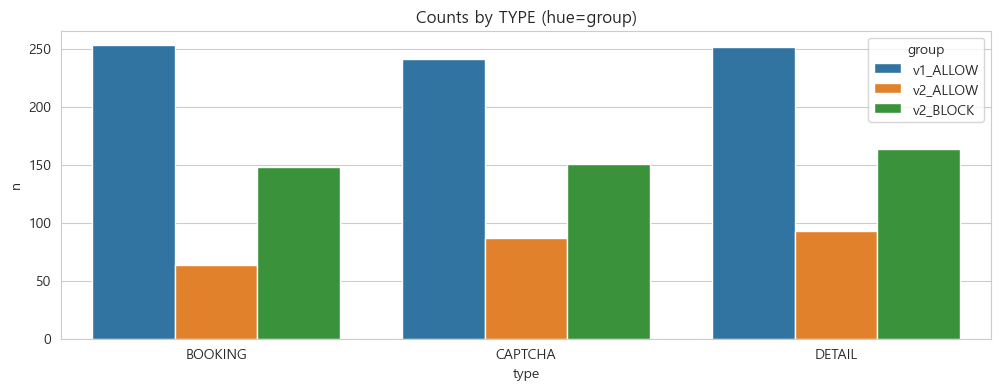

In [9]:
plt.figure(figsize=(12, 4))
sns.barplot(data=count_table, x="type", y="n", hue="group")
plt.title("Counts by TYPE (hue=group)")
plt.show()

In [10]:
# 결측률(전체)
missing_overall = df[feature_cols].isna().mean().sort_values(ascending=False)
missing_overall_tbl = pd.DataFrame({"missing_rate": missing_overall, "missing_pct": (missing_overall * 100).round(2)})
missing_overall_tbl.head(30)

,missing_rate,missing_pct
mouse_hover_dwell_time_ms,0.600138,60.01
time_from_element_visible_to_click_ms,0.513421,51.34
time_from_element_clickable_to_click_ms,0.513421,51.34
immediate_post_render_click_rate,0.494838,49.48
mouse_jerk_mean,0.236063,23.61
click_position_repeat_rate,0.146593,14.66
click_sequence_consistency_score,0.146593,14.66
mouse_acceleration_mean,0.116999,11.70
mouse_speed_change_mean,0.116999,11.70
mouse_path_curvature_mean,0.116999,11.70


In [11]:
# 결측률(TYPE별)
thr = float(MISSING_DROP_THRESHOLD)
drop_by_type = []
for t, sub in df.groupby("type"):
    mr = sub[feature_cols].isna().mean()
    drop = sorted(mr[mr > thr].index.tolist())
    drop_by_type.append({"type": t, "drop_count": len(drop), "drop_features": drop})

pd.DataFrame(drop_by_type)

,type,drop_count,drop_features
0,BOOKING,4,"[immediate_post_render_click_rate, mouse_hover_dwell_time_ms, time_from_element_clickable_to_click_ms, time_from_element_visible_to_click_ms]"
1,CAPTCHA,5,"[immediate_post_render_click_rate, mouse_hover_dwell_time_ms, mouse_jerk_mean, time_from_element_clickable_to_click_ms, time_from_element_visible_to_click_ms]"
2,DETAIL,17,"[click_position_repeat_rate, click_sequence_consistency_score, edge_or_fixed_point_visit_rate, immediate_post_render_click_rate, mouse_acceleration_mean, mouse_avg_speed_px_per_ms, mouse_direction_change_count, mouse_hover_dwell_time_ms, mouse_jerk_mean, mouse_max_speed_px_per_ms, mouse_path_curvature_mean, mouse_path_straightness_score, mouse_speed_change_mean, mouse_stop_segment_count, mouse_total_travel_distance_px, time_from_element_clickable_to_click_ms, time_from_element_visible_to_click_ms]"


In [12]:
def smd(a: np.ndarray, b: np.ndarray) -> float:
    """Standardized Mean Difference (SMD). NaN은 제외하고 계산."""
    a = a.astype(float)
    b = b.astype(float)
    a = a[~np.isnan(a)]
    b = b[~np.isnan(b)]
    if len(a) < 2 or len(b) < 2:
        return np.nan
    mean_a = float(np.mean(a))
    mean_b = float(np.mean(b))
    var_a = float(np.var(a, ddof=1))
    var_b = float(np.var(b, ddof=1))
    pooled = np.sqrt((var_a + var_b) / 2.0)
    if pooled == 0:
        return np.nan
    return (mean_a - mean_b) / pooled


def compute_smd_table(df_sub: pd.DataFrame, *, group_a: str, group_b: str, cols: List[str]) -> pd.DataFrame:
    rows = []
    for c in cols:
        x = df_sub.loc[df_sub["group"] == group_a, c].to_numpy(dtype=float)
        y = df_sub.loc[df_sub["group"] == group_b, c].to_numpy(dtype=float)
        v = smd(x, y)
        rows.append({"feature": c, "SMD": v, "abs_SMD": np.nan if np.isnan(v) else abs(v)})
    out = pd.DataFrame(rows).sort_values("abs_SMD", ascending=False)
    return out


In [13]:
# TYPE별 SMD 계산
# 비교1: v2_BLOCK vs v2_ALLOW
# 비교2: v2_ALLOW vs v1_ALLOW

SMD_TOP_N = 20

for t in TYPES:
    sub = df[df["type"] == t].copy()
    print("\n" + "=" * 90)
    print(f"TYPE={t} | counts=", sub.groupby("group").size().to_dict())

    if {"v2_BLOCK", "v2_ALLOW"}.issubset(set(sub["group"].unique())):
        tbl = compute_smd_table(sub, group_a="v2_BLOCK", group_b="v2_ALLOW", cols=feature_cols)
        print("\n[v2_BLOCK vs v2_ALLOW] TOP SMD")
        display(tbl.head(SMD_TOP_N))
    else:
        print("\n[v2_BLOCK vs v2_ALLOW] 데이터가 부족해서 스킵")

    if {"v2_ALLOW", "v1_ALLOW"}.issubset(set(sub["group"].unique())):
        tbl = compute_smd_table(sub, group_a="v2_ALLOW", group_b="v1_ALLOW", cols=feature_cols)
        print("\n[v2_ALLOW vs v1_ALLOW] TOP SMD")
        display(tbl.head(SMD_TOP_N))
    else:
        print("\n[v2_ALLOW vs v1_ALLOW] 데이터가 부족해서 스킵")



TYPE=DETAIL | counts= {'v1_ALLOW': 252, 'v2_ALLOW': 93, 'v2_BLOCK': 164}

[v2_BLOCK vs v2_ALLOW] TOP SMD


,feature,SMD,abs_SMD
29,pre_click_path_500ms_straightness,-2.076754,2.076754
8,pre_click_mousemove_count,-1.600828,1.600828
27,pre_click_path_300ms_straightness,-1.469105,1.469105
24,mousemove_event_rate,-1.379170,1.379170
17,mouse_jerk_mean,1.374241,1.374241
14,mouse_max_speed_px_per_ms,1.149684,1.149684
12,mouse_total_travel_distance_px,1.132718,1.132718
15,mouse_speed_change_mean,1.128728,1.128728
28,pre_click_path_500ms_total_distance_px,-1.090188,1.090188
16,mouse_acceleration_mean,1.075800,1.075800



[v2_ALLOW vs v1_ALLOW] TOP SMD


,feature,SMD,abs_SMD
21,mouse_overshoot_flag,0.567014,0.567014
9,pre_click_hover_time_ms,0.434329,0.434329
20,mouse_direction_change_count,0.363737,0.363737
23,mouse_stop_segment_count,0.299404,0.299404
18,mouse_path_straightness_score,-0.274079,0.274079
17,mouse_jerk_mean,-0.246006,0.246006
6,misclick_rate,0.241632,0.241632
4,click_position_repeat_rate,-0.190719,0.190719
25,edge_or_fixed_point_visit_rate,0.179175,0.179175
5,double_click_rate,0.172897,0.172897



TYPE=CAPTCHA | counts= {'v1_ALLOW': 241, 'v2_ALLOW': 87, 'v2_BLOCK': 151}

[v2_BLOCK vs v2_ALLOW] TOP SMD


...

,feature,SMD,abs_SMD
3,click_sequence_consistency_score,2.375672,2.375672
21,mouse_overshoot_flag,1.072502,1.072502
6,misclick_rate,0.716175,0.716175
20,mouse_direction_change_count,0.539058,0.539058
28,pre_click_path_500ms_total_distance_px,0.432546,0.432546
23,mouse_stop_segment_count,0.344616,0.344616
7,reclick_rate,0.308488,0.308488
17,mouse_jerk_mean,-0.300338,0.300338
24,mousemove_event_rate,0.295283,0.295283
18,mouse_path_straightness_score,-0.277602,0.277602



TYPE=BOOKING | counts= {'v1_ALLOW': 253, 'v2_ALLOW': 64, 'v2_BLOCK': 148}

[v2_BLOCK vs v2_ALLOW] TOP SMD


,feature,SMD,abs_SMD
5,double_click_rate,4.129241,4.129241
8,pre_click_mousemove_count,-3.309430,3.309430
24,mousemove_event_rate,-3.290885,3.290885
28,pre_click_path_500ms_total_distance_px,2.692653,2.692653
27,pre_click_path_300ms_straightness,-2.288212,2.288212
19,mouse_path_curvature_mean,-1.949726,1.949726
20,mouse_direction_change_count,-1.897634,1.897634
17,mouse_jerk_mean,-1.862894,1.862894
15,mouse_speed_change_mean,1.540715,1.540715
16,mouse_acceleration_mean,-1.536442,1.536442



[v2_ALLOW vs v1_ALLOW] TOP SMD


,feature,SMD,abs_SMD
21,mouse_overshoot_flag,1.063528,1.063528
24,mousemove_event_rate,0.966963,0.966963
13,mouse_avg_speed_px_per_ms,0.761082,0.761082
3,click_sequence_consistency_score,0.756721,0.756721
6,misclick_rate,0.538941,0.538941
23,mouse_stop_segment_count,-0.505903,0.505903
12,mouse_total_travel_distance_px,-0.464160,0.464160
7,reclick_rate,0.445697,0.445697
8,pre_click_mousemove_count,0.389338,0.389338
22,mouse_hover_dwell_time_ms,-0.378538,0.378538


### (추가) 높은 SMD feature 강조(주황색) + High-SMD PCA

- 높은 SMD(절대값) feature는 표/제목에서 **주황색(#f59e0b)** 으로 표시
- 높은 SMD feature만 골라서 PCA를 한 번 더 수행

비교 기준
- 비교1: `v2_BLOCK` vs `v2_ALLOW`
- 비교2: `v2_ALLOW` vs `v1_ALLOW`


In [ ]:
# 높은 SMD 강조 기준
ORANGE_ABS_SMD = 0.5

# High-SMD PCA에 사용할 feature 개수(기본: 상위 15개)
HIGH_SMD_PCA_TOP_N = 15


In [ ]:
def style_high_smd(df_smd: pd.DataFrame, *, threshold: float):
    """abs_SMD가 threshold 이상인 row를 주황색으로 하이라이트."""
    def _row_style(row):
        try:
            v = float(row.get("abs_SMD"))
        except Exception:
            v = np.nan
        is_high = (not np.isnan(v)) and (v >= threshold)
        if not is_high:
            return [""] * len(row)
        return ["background-color: #f59e0b"] * len(row)

    return df_smd.style.apply(_row_style, axis=1)


HIGH_SMD_BLOCK_VS_ALLOW: dict[str, set[str]] = {}
HIGH_SMD_ALLOW_VS_V1: dict[str, set[str]] = {}
HIGH_SMD_UNION_BY_TYPE: dict[str, set[str]] = {}

for t in TYPES:
    sub = df[df["type"] == t].copy()

    # 비교1: v2_BLOCK vs v2_ALLOW
    if {"v2_BLOCK", "v2_ALLOW"}.issubset(set(sub["group"].unique())):
        tbl1 = compute_smd_table(sub, group_a="v2_BLOCK", group_b="v2_ALLOW", cols=feature_cols)
        high1 = set(tbl1[pd.notna(tbl1["abs_SMD"]) & (tbl1["abs_SMD"] >= ORANGE_ABS_SMD)]["feature"].tolist())
        if not high1:
            high1 = set(tbl1.head(HIGH_SMD_PCA_TOP_N)["feature"].tolist())
        HIGH_SMD_BLOCK_VS_ALLOW[t] = high1

        print("\n" + "=" * 90)
        print(f"TYPE={t} | [v2_BLOCK vs v2_ALLOW] high_smd_count={len(high1)} (threshold={ORANGE_ABS_SMD})")
        display(style_high_smd(tbl1.head(30), threshold=ORANGE_ABS_SMD))
    else:
        HIGH_SMD_BLOCK_VS_ALLOW[t] = set()

    # 비교2: v2_ALLOW vs v1_ALLOW
    if {"v2_ALLOW", "v1_ALLOW"}.issubset(set(sub["group"].unique())):
        tbl2 = compute_smd_table(sub, group_a="v2_ALLOW", group_b="v1_ALLOW", cols=feature_cols)
        high2 = set(tbl2[pd.notna(tbl2["abs_SMD"]) & (tbl2["abs_SMD"] >= ORANGE_ABS_SMD)]["feature"].tolist())
        if not high2:
            high2 = set(tbl2.head(HIGH_SMD_PCA_TOP_N)["feature"].tolist())
        HIGH_SMD_ALLOW_VS_V1[t] = high2

        print(f"TYPE={t} | [v2_ALLOW vs v1_ALLOW] high_smd_count={len(high2)} (threshold={ORANGE_ABS_SMD})")
        display(style_high_smd(tbl2.head(30), threshold=ORANGE_ABS_SMD))
    else:
        HIGH_SMD_ALLOW_VS_V1[t] = set()

    HIGH_SMD_UNION_BY_TYPE[t] = set(HIGH_SMD_BLOCK_VS_ALLOW.get(t, set())) | set(HIGH_SMD_ALLOW_VS_V1.get(t, set()))

print("\n[INFO] HIGH_SMD_UNION_BY_TYPE sizes:")
print({k: len(v) for k, v in HIGH_SMD_UNION_BY_TYPE.items()})


In [ ]:
def pca_plot_for_features(df_sub: pd.DataFrame, *, features: List[str], title: str) -> None:
    if df_sub.empty:
        print("skip empty:", title)
        return
    features = [f for f in features if f in feature_cols]
    if not features:
        print("skip no features:", title)
        return

    X = df_sub[features].apply(pd.to_numeric, errors="coerce")
    imputer = SimpleImputer(strategy="median")
    scaler = StandardScaler()
    pca = PCA(n_components=2, random_state=42)

    X_imp = imputer.fit_transform(X)
    X_scaled = scaler.fit_transform(X_imp)
    X_pca = pca.fit_transform(X_scaled)

    plot_df = pd.DataFrame({
        "pc1": X_pca[:, 0],
        "pc2": X_pca[:, 1],
        "group": df_sub["group"].values,
    })

    plt.figure(figsize=(7, 5))
    sns.scatterplot(data=plot_df, x="pc1", y="pc2", hue="group", alpha=0.7)
    plt.title(title, color="#f59e0b")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()


for t in TYPES:
    sub = df[(df["type"] == t) & (df["group"].isin(["v1_ALLOW", "v2_ALLOW", "v2_BLOCK"]))].copy()

    f1 = sorted(HIGH_SMD_BLOCK_VS_ALLOW.get(t, set()))
    if f1:
        pca_plot_for_features(
            sub,
            features=f1,
            title=f"PCA (High-SMD only) | TYPE={t} | 기준: v2_BLOCK vs v2_ALLOW | n_feat={len(f1)}",
        )

    f2 = sorted(HIGH_SMD_ALLOW_VS_V1.get(t, set()))
    if f2:
        pca_plot_for_features(
            sub,
            features=f2,
            title=f"PCA (High-SMD only) | TYPE={t} | 기준: v2_ALLOW vs v1_ALLOW | n_feat={len(f2)}",
        )


### 3-1 데이터 분포 시각화 (boxplot)

eda_chan.ipynb처럼 boxplot을 그리되, x축은 `v1_ALLOW / v2_ALLOW / v2_BLOCK`을 사용합니다.


In [14]:
N_COLS = 3
N_FEATURES = 6
MAX_STRIP_PER_LABEL = 300


def draw_boxplot_by_type(type_name: str, features: List[str], *, highlight: set[str] | None = None) -> None:
    features = [f for f in features if f in feature_cols]
    if not features:
        print("skip type:", type_name)
        return

    sub = df[df["type"] == type_name].copy()
    sub = sub[sub["group"].isin(["v1_ALLOW", "v2_ALLOW", "v2_BLOCK"])].copy()

    for start in range(0, len(features), N_FEATURES):
        subset = features[start : start + N_FEATURES]
        rows = int(np.ceil(len(subset) / N_COLS))

        fig, axes = plt.subplots(rows, N_COLS, figsize=(16, 4.6 * rows))
        axes = np.array(axes).reshape(rows, N_COLS)

        for i, feature in enumerate(subset):
            r = i // N_COLS
            c = i % N_COLS
            ax = axes[r, c]

            s = pd.to_numeric(sub[feature], errors="coerce")
            plot_df = pd.DataFrame({"group": sub["group"], "value": s}).dropna()

            feature_ko = FEATURE_NAME_KR.get(feature, feature)
            if plot_df.empty:
                ax.set_title(f"[ {feature_ko} ]\n[ {feature} ]")
                ax.axis("off")
                continue

            sns.boxplot(
                data=plot_df,
                x="group",
                y="value",
                order=["v1_ALLOW", "v2_ALLOW", "v2_BLOCK"],
                ax=ax,
                fliersize=2,
            )

            # strip(샘플링)
            strip_parts = []
            for g in ["v1_ALLOW", "v2_ALLOW", "v2_BLOCK"]:
                part = plot_df[plot_df["group"] == g]
                if part.empty:
                    continue
                if len(part) > MAX_STRIP_PER_LABEL:
                    part = part.sample(MAX_STRIP_PER_LABEL, random_state=42)
                strip_parts.append(part)
            if strip_parts:
                strip_df = pd.concat(strip_parts, axis=0)
                sns.stripplot(
                    data=strip_df,
                    x="group",
                    y="value",
                    order=["v1_ALLOW", "v2_ALLOW", "v2_BLOCK"],
                    ax=ax,
                    size=2,
                    alpha=0.25,
                    jitter=0.25,
                    color="#111827",
                )

            is_high = bool(highlight) and (feature in highlight)
            title_color = "#f59e0b" if is_high else "black"  # 주황색(높은 SMD)
            ax.set_title(f"{type_name} | {feature_ko}\n{feature}", color=title_color)

        # 빈 subplot 숨김
        for j in range(len(subset), rows * N_COLS):
            rr = j // N_COLS
            cc = j % N_COLS
            axes[rr, cc].axis("off")

        plt.tight_layout()
        plt.show()


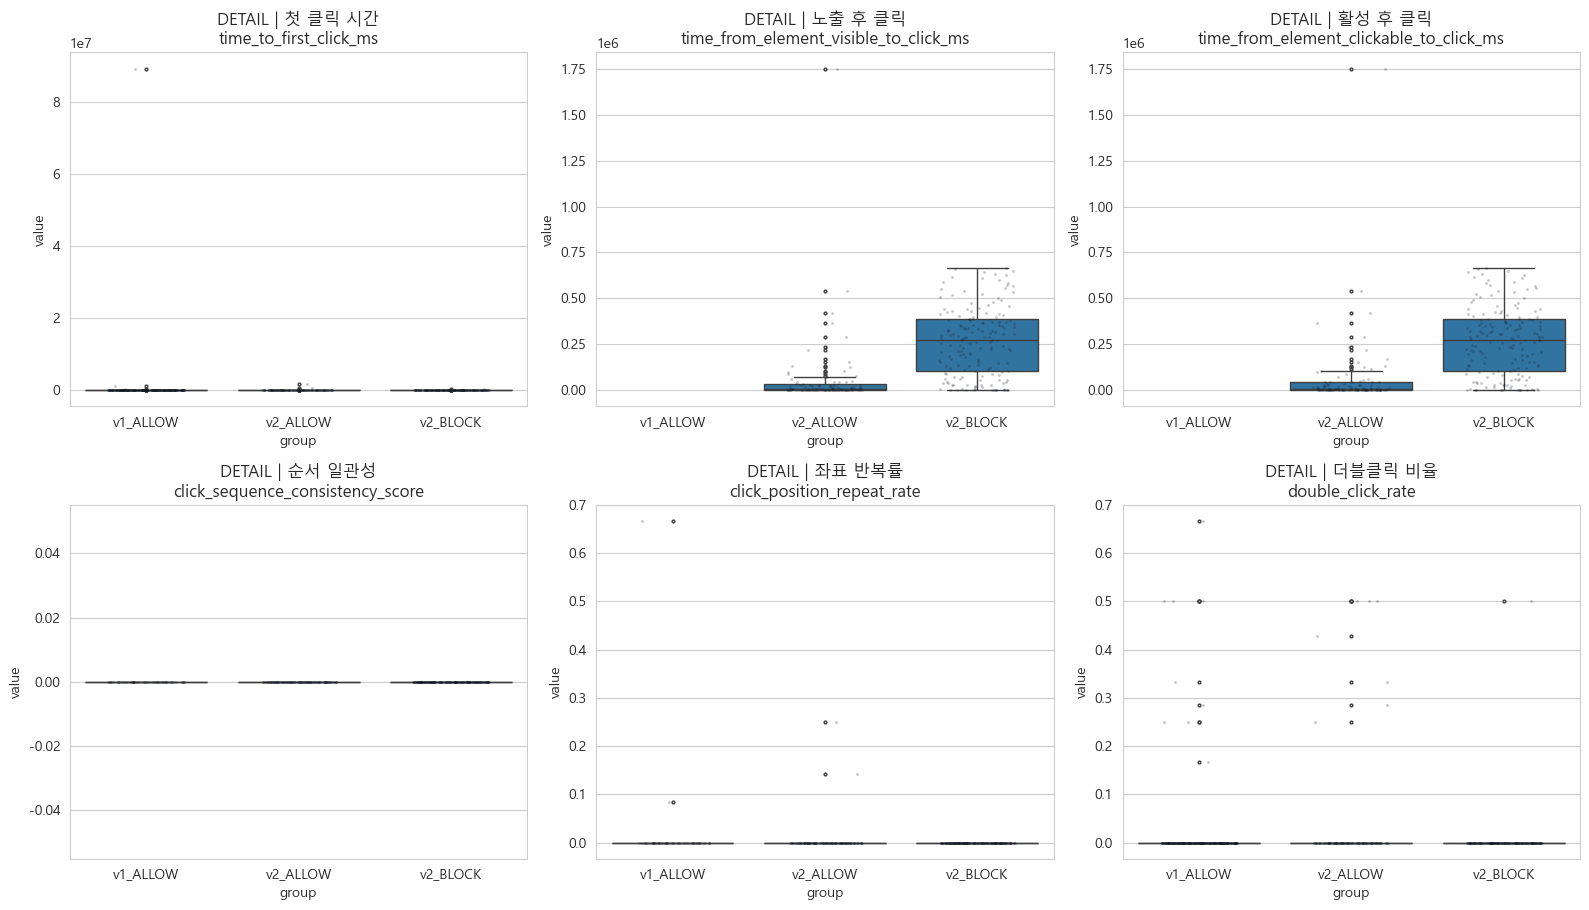

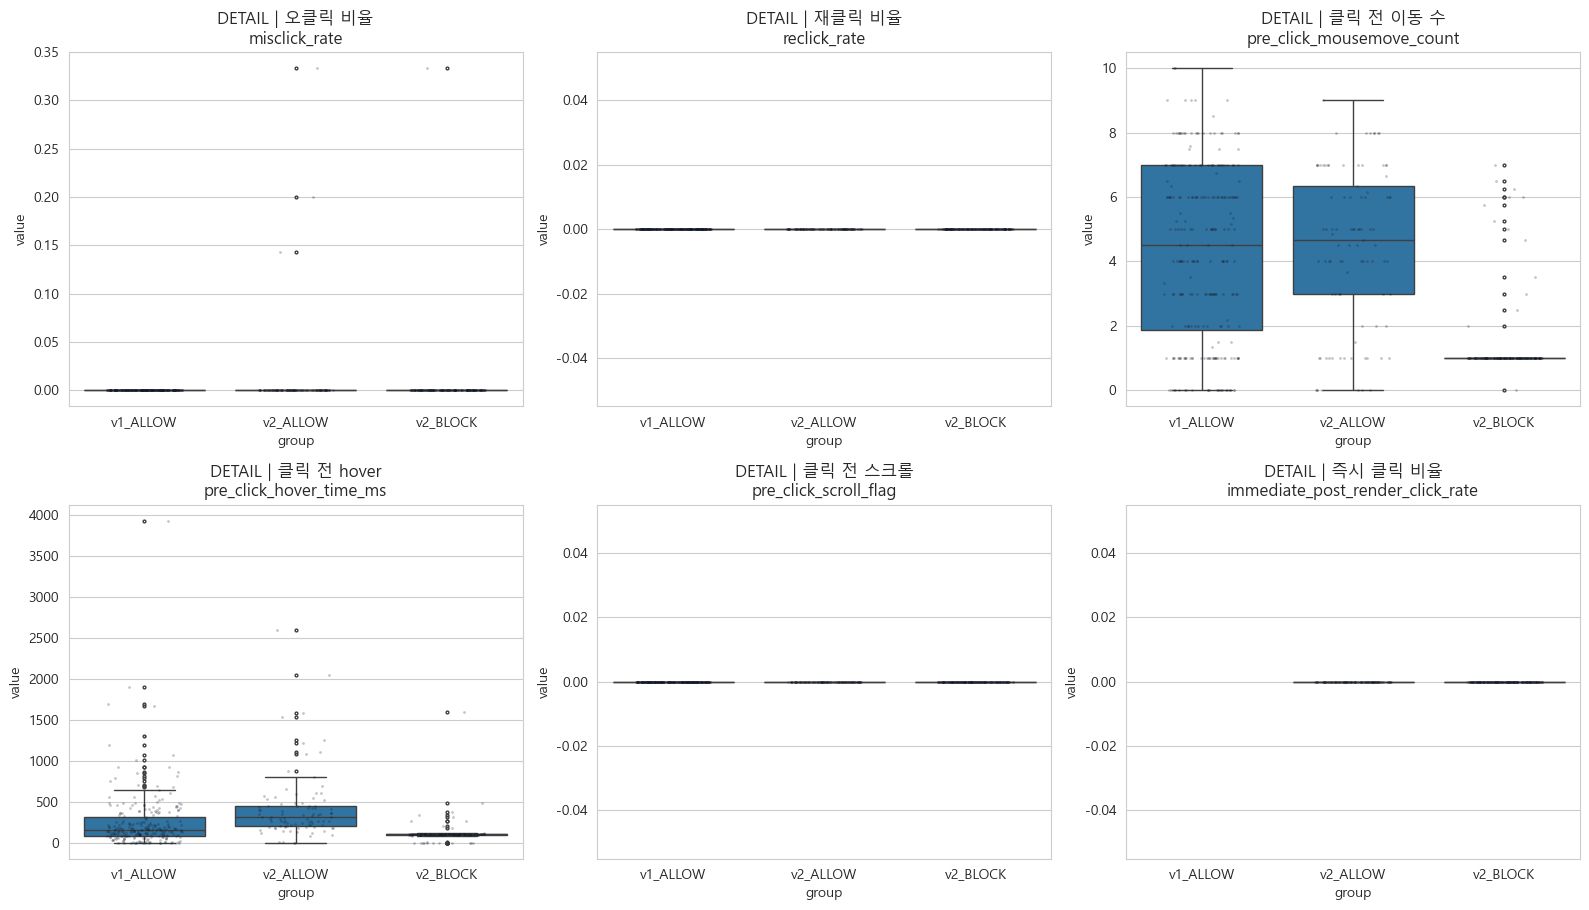

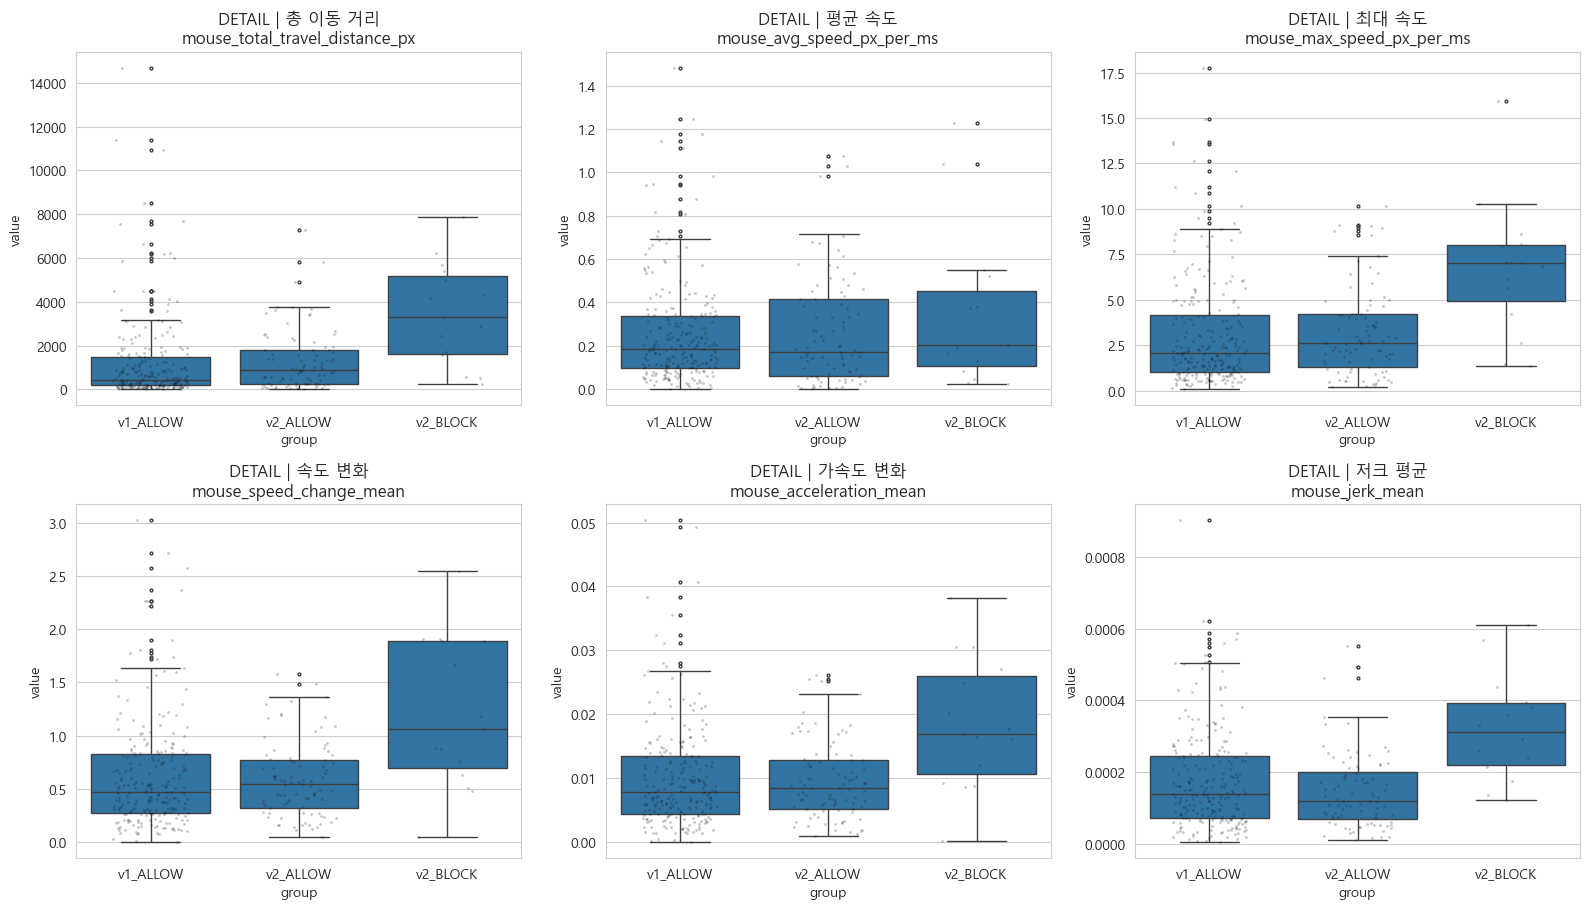

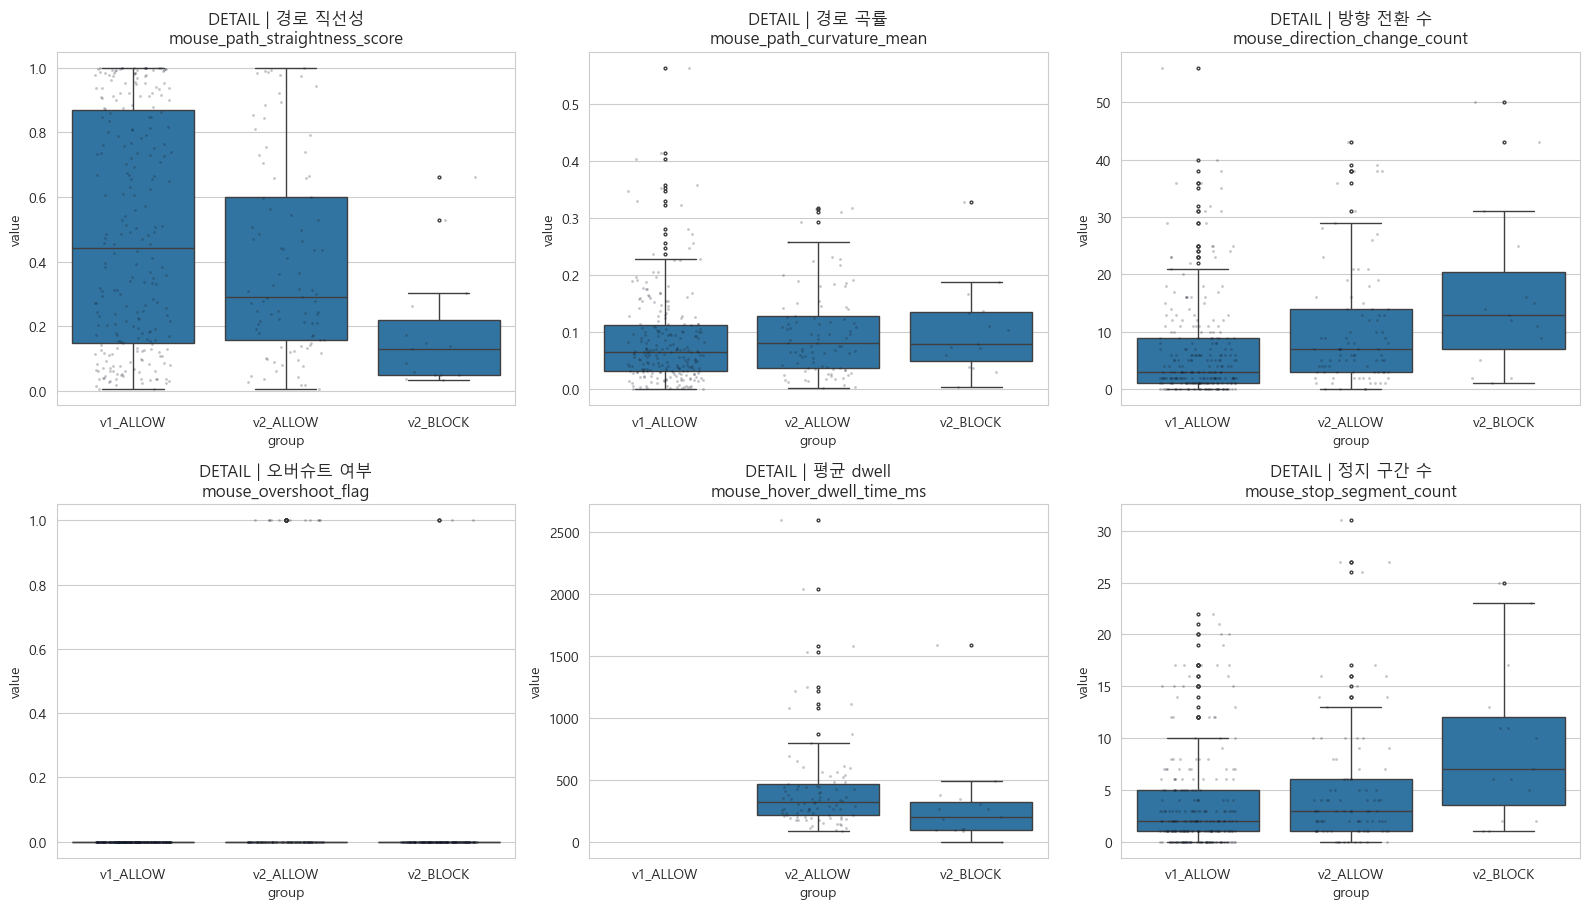

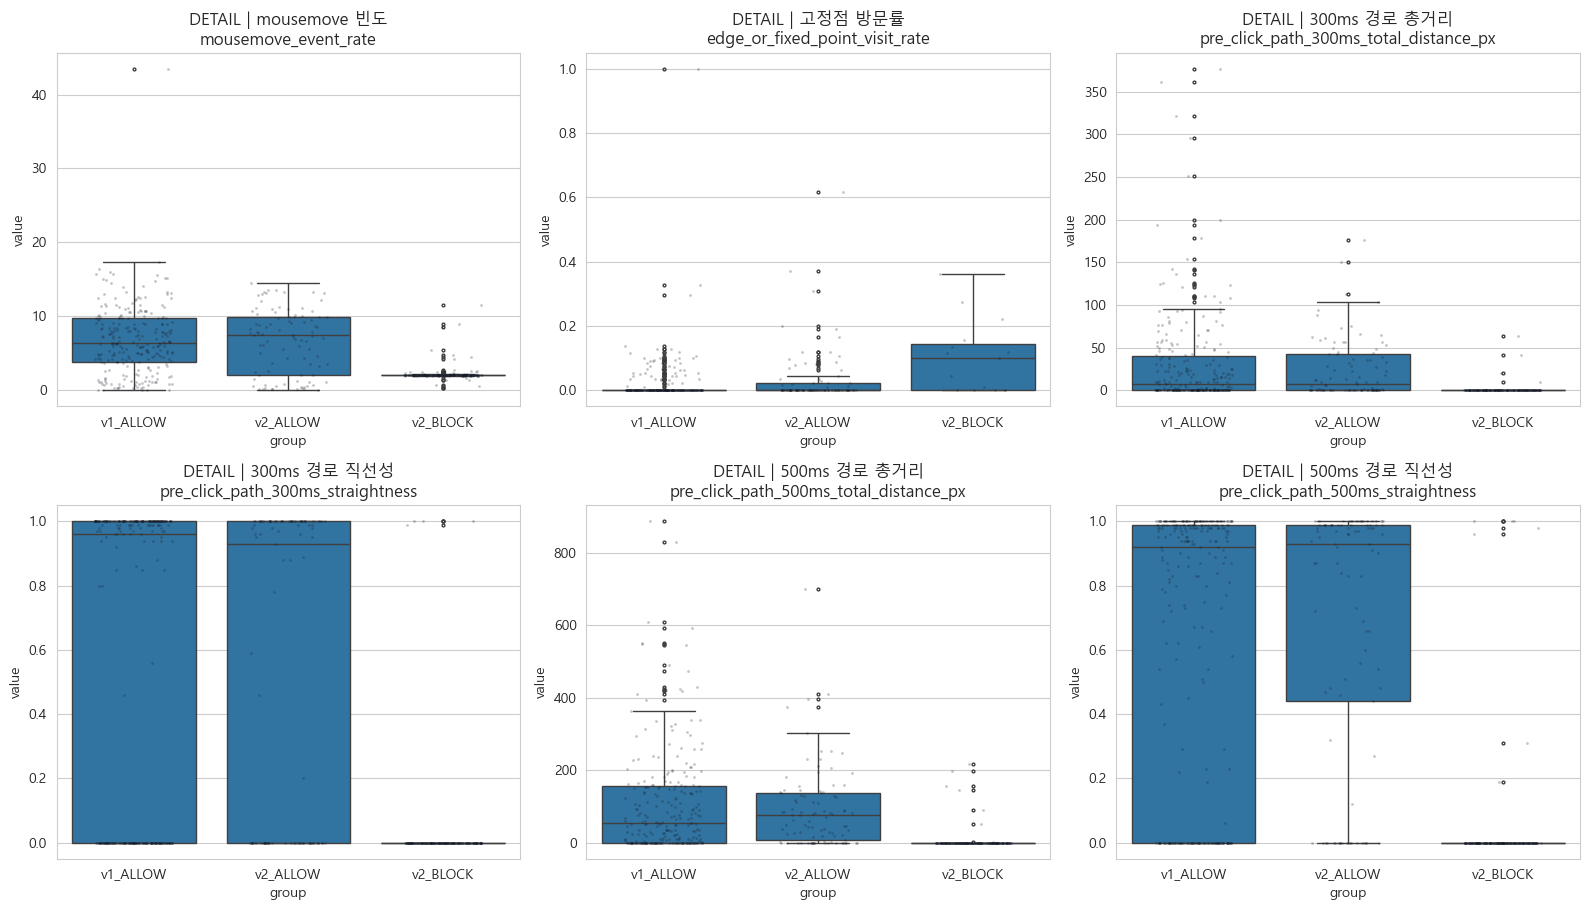

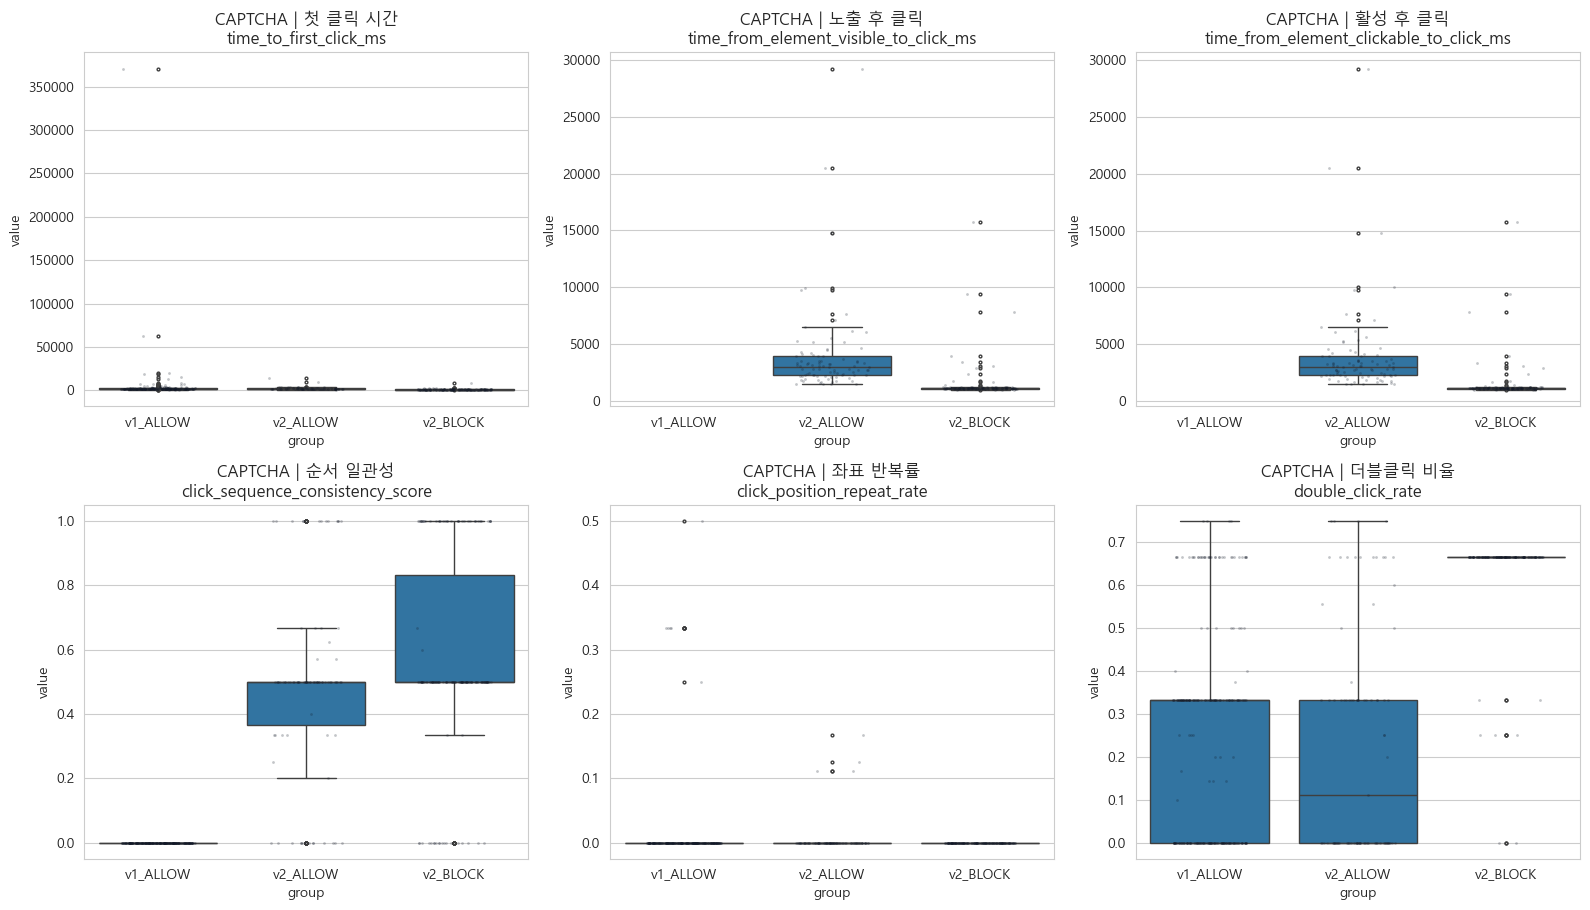

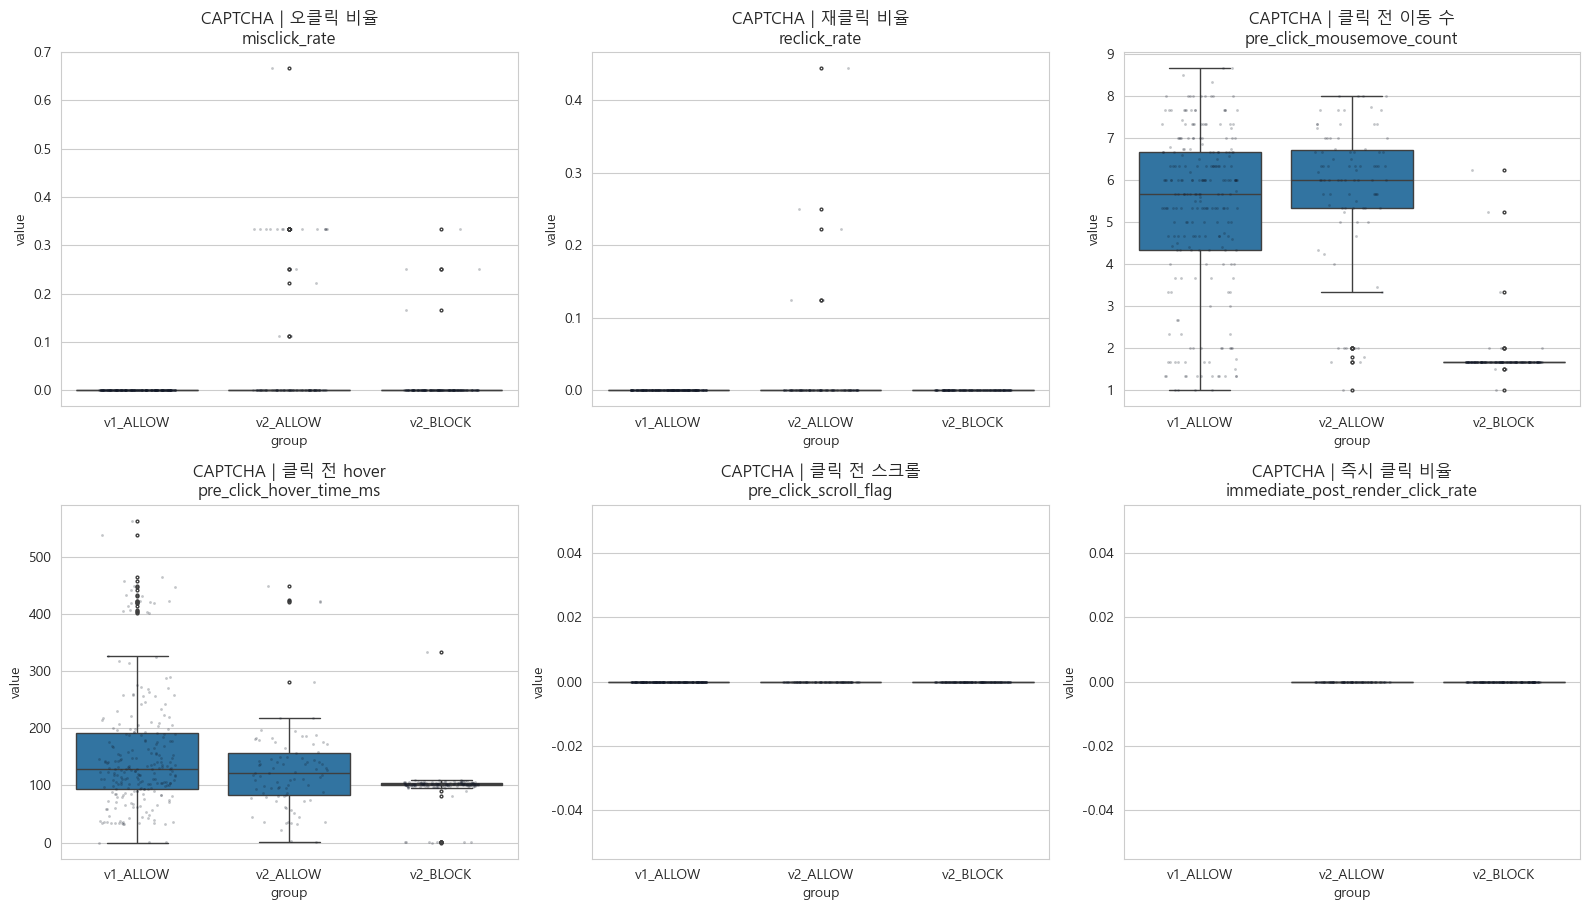

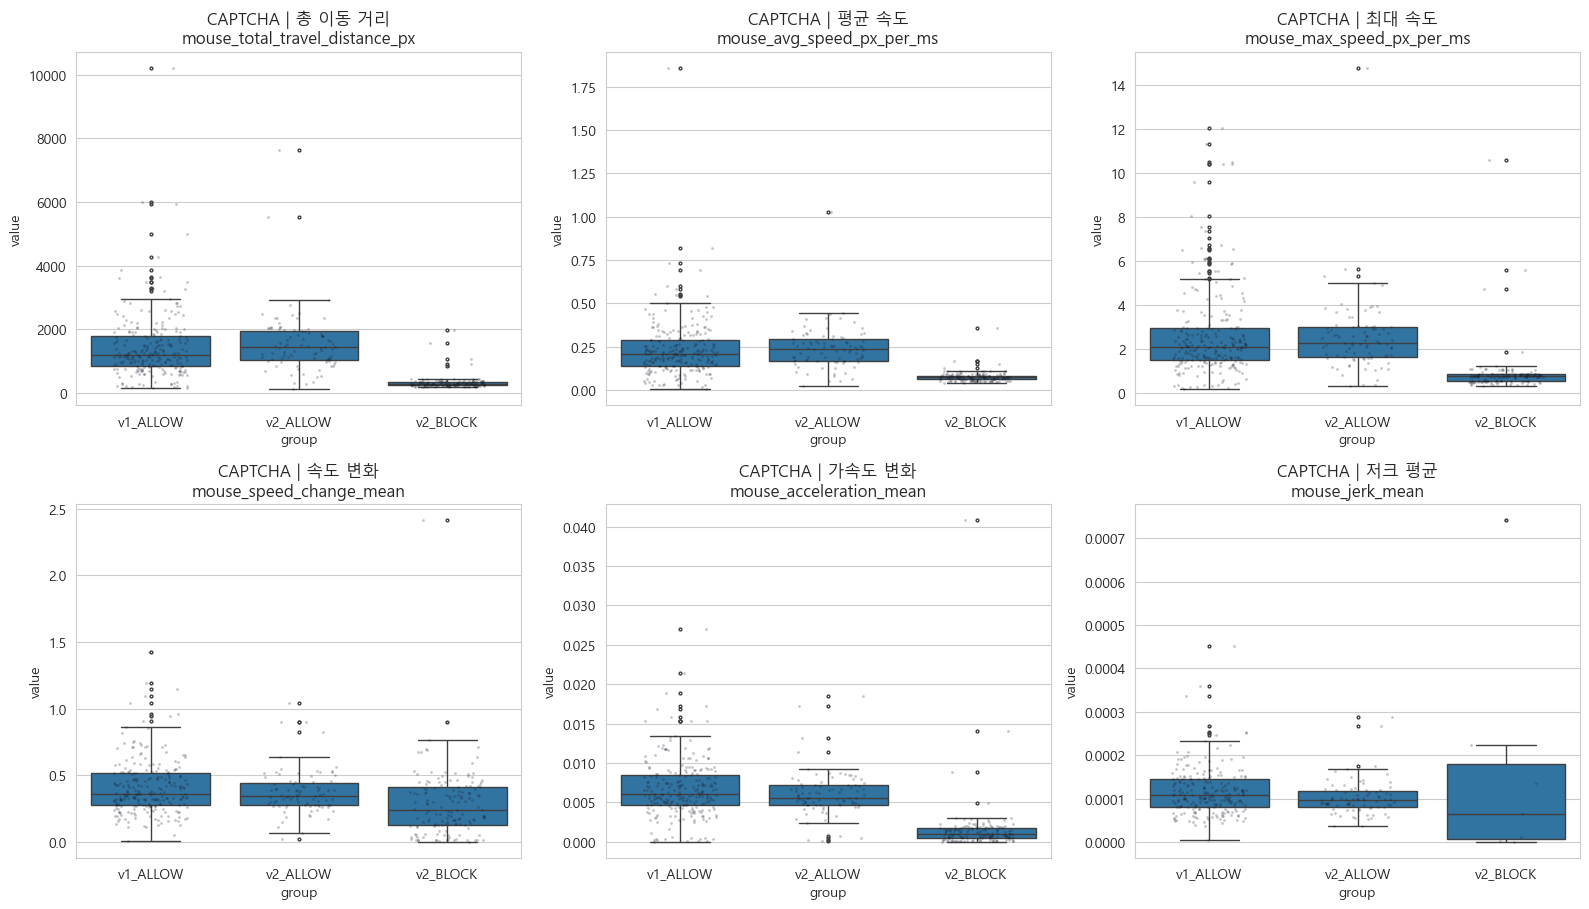

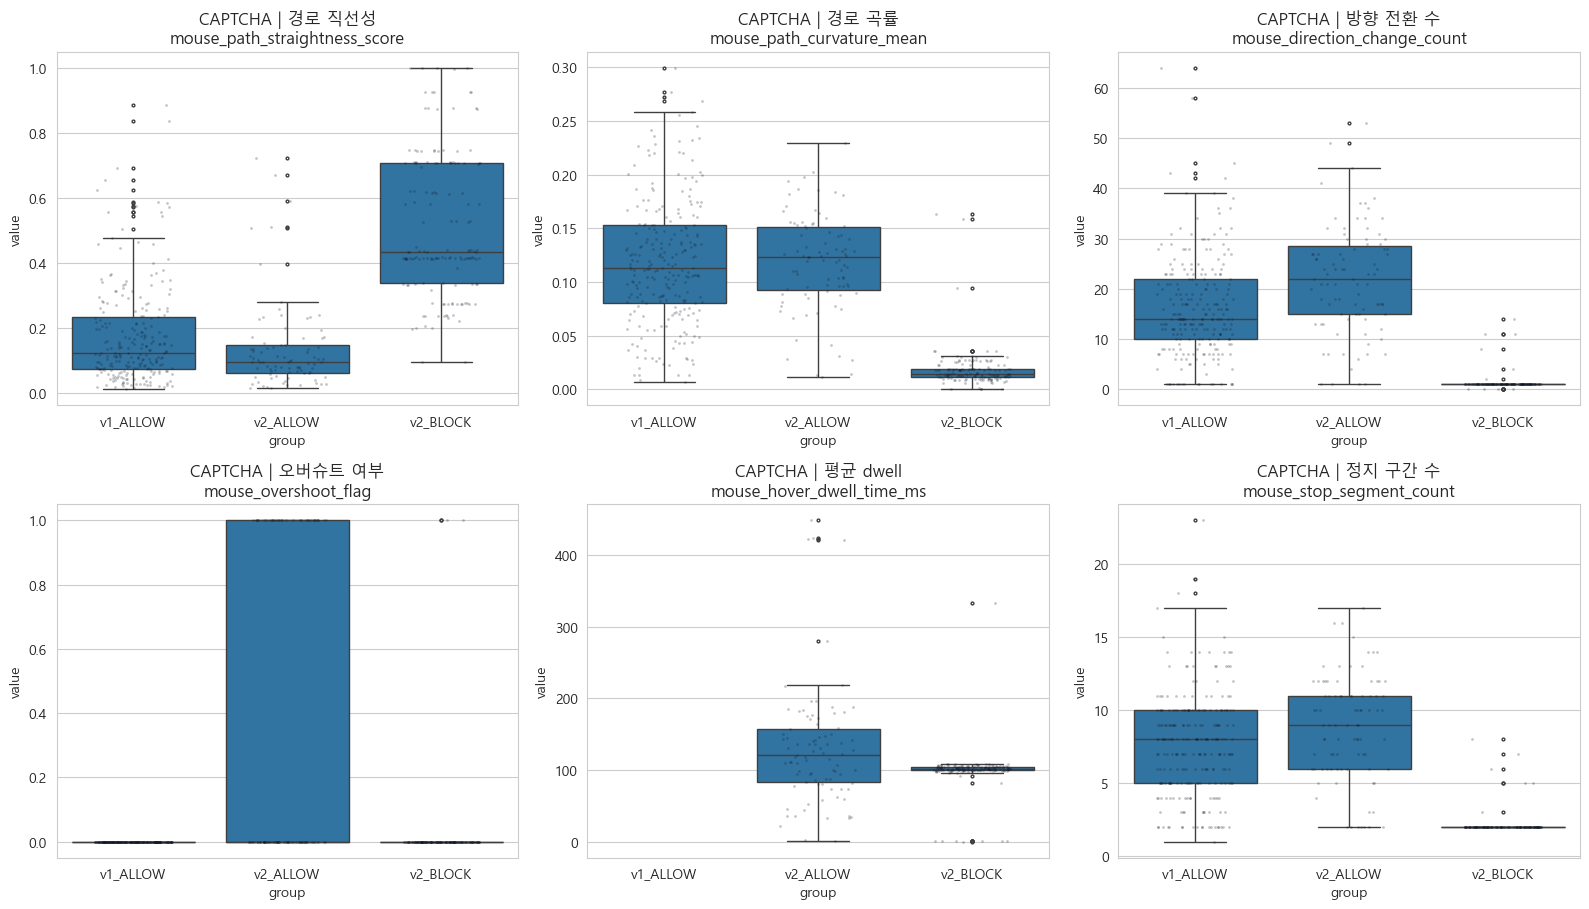

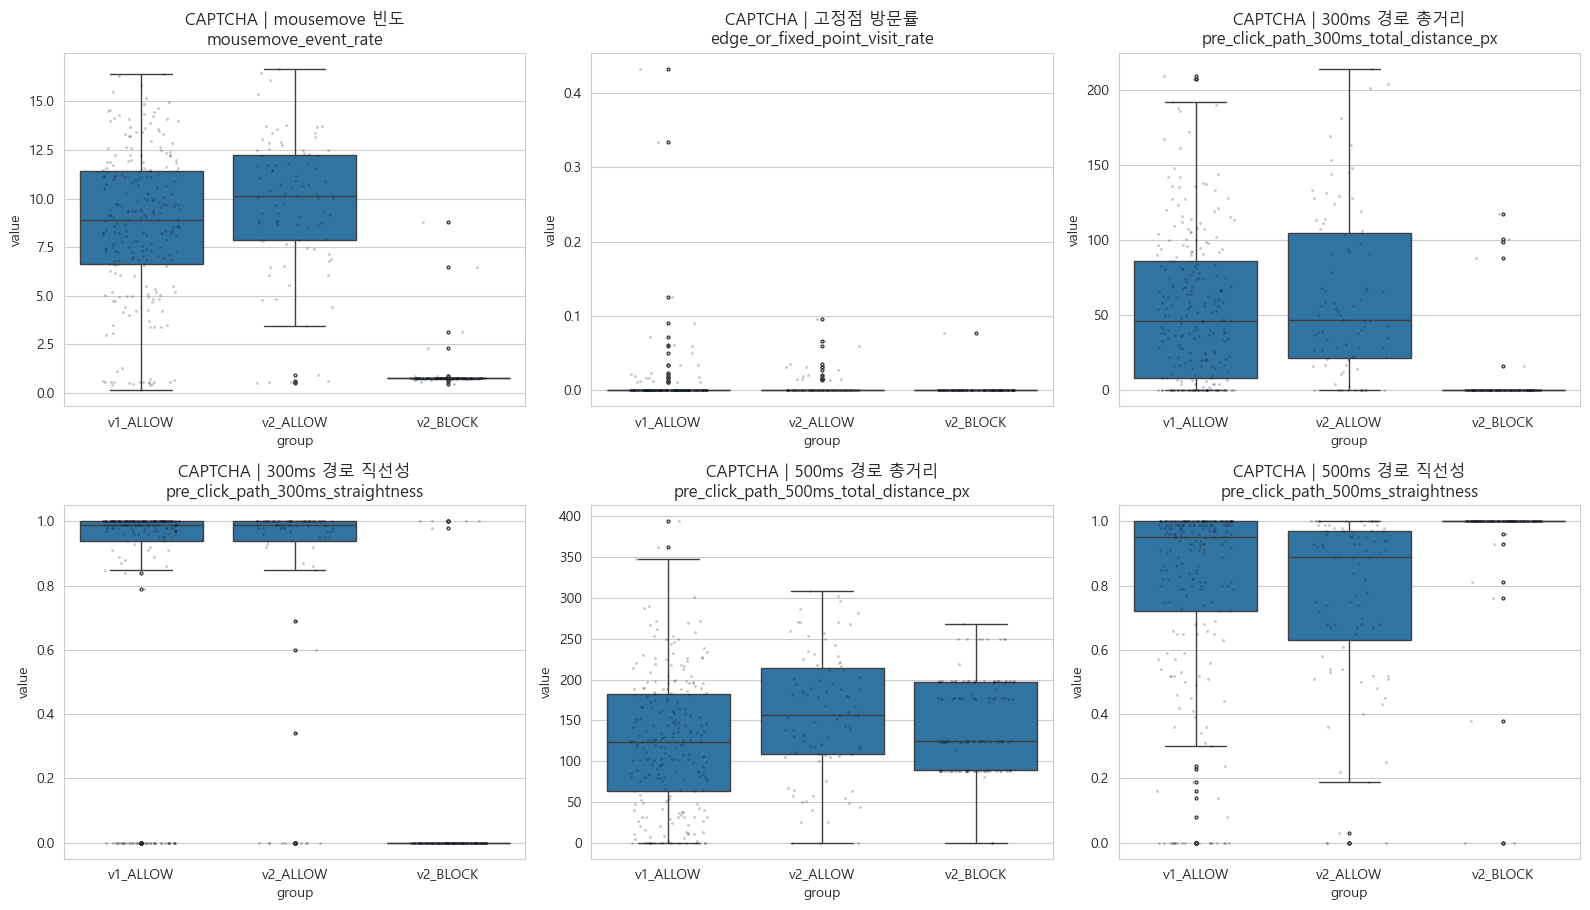

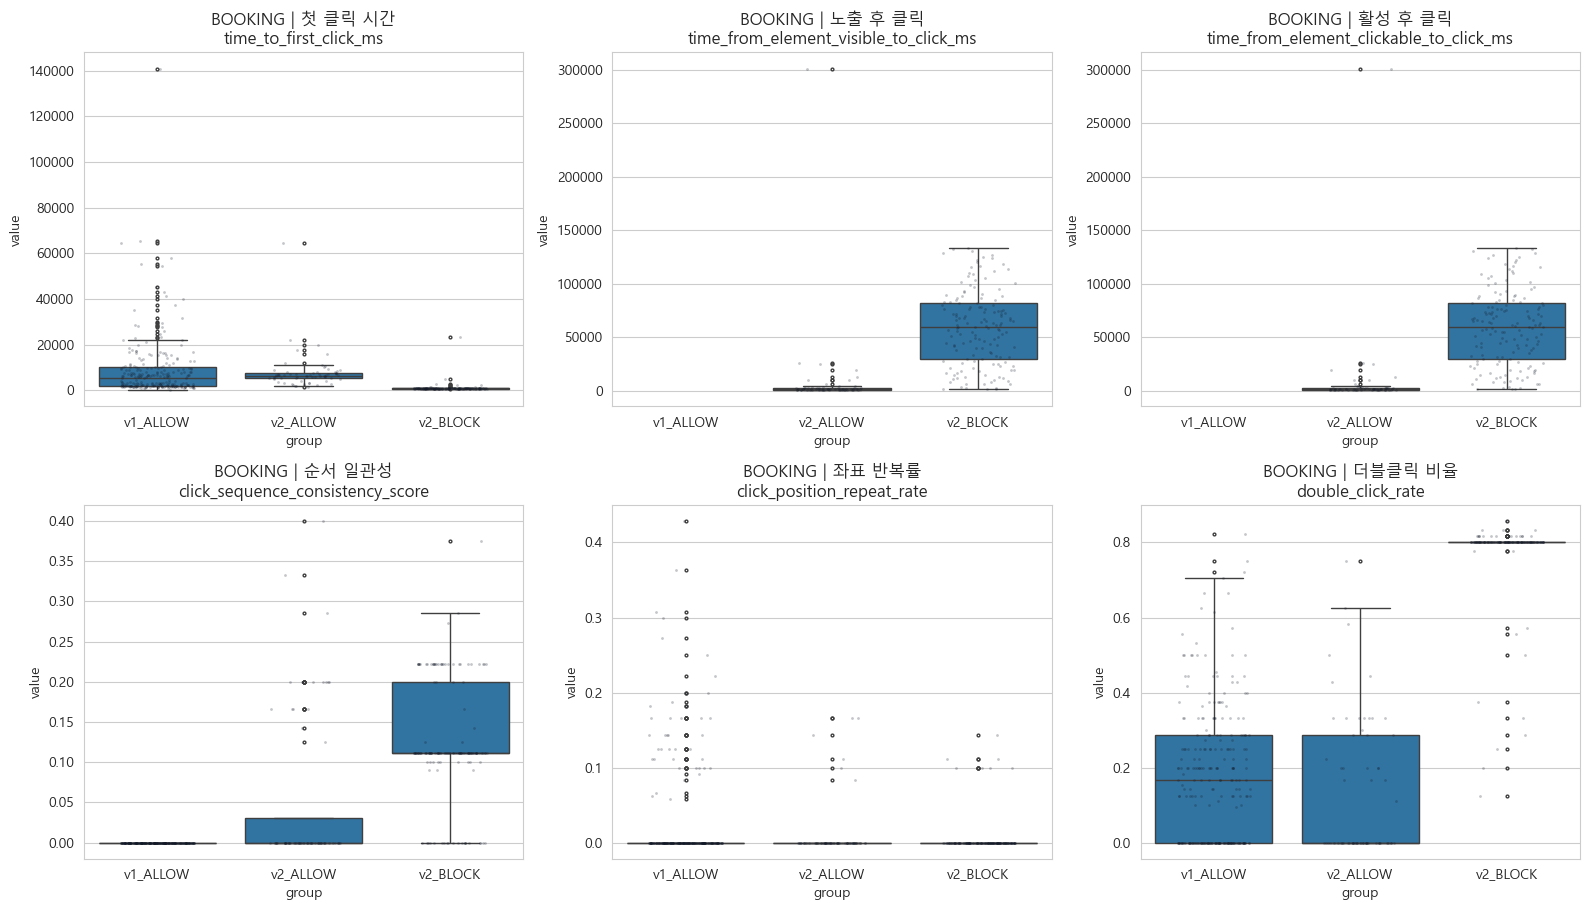

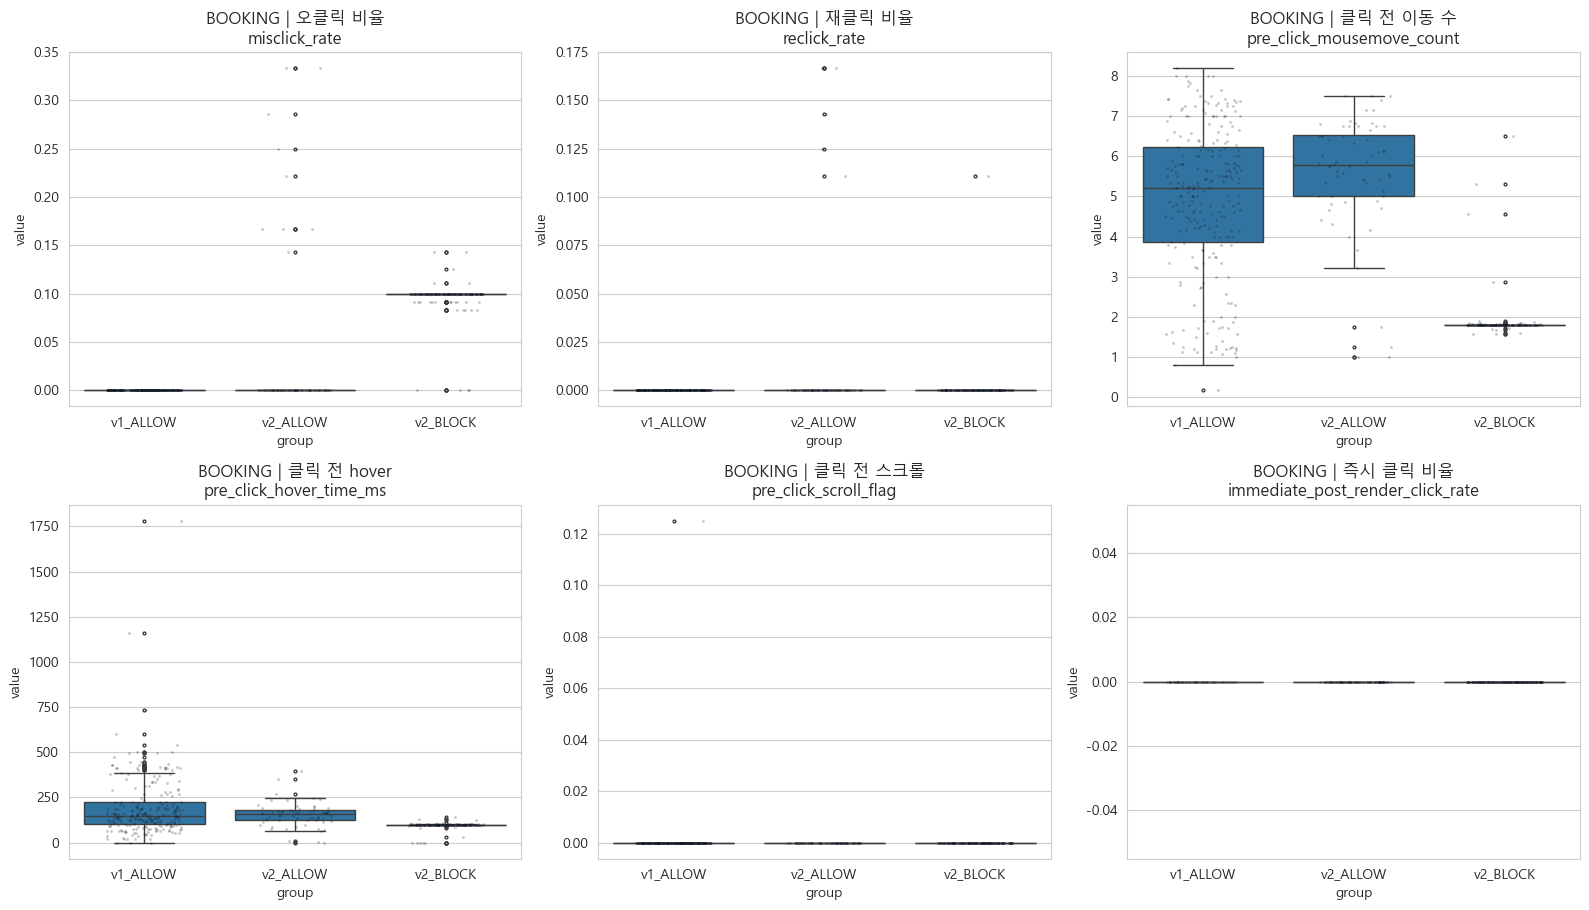

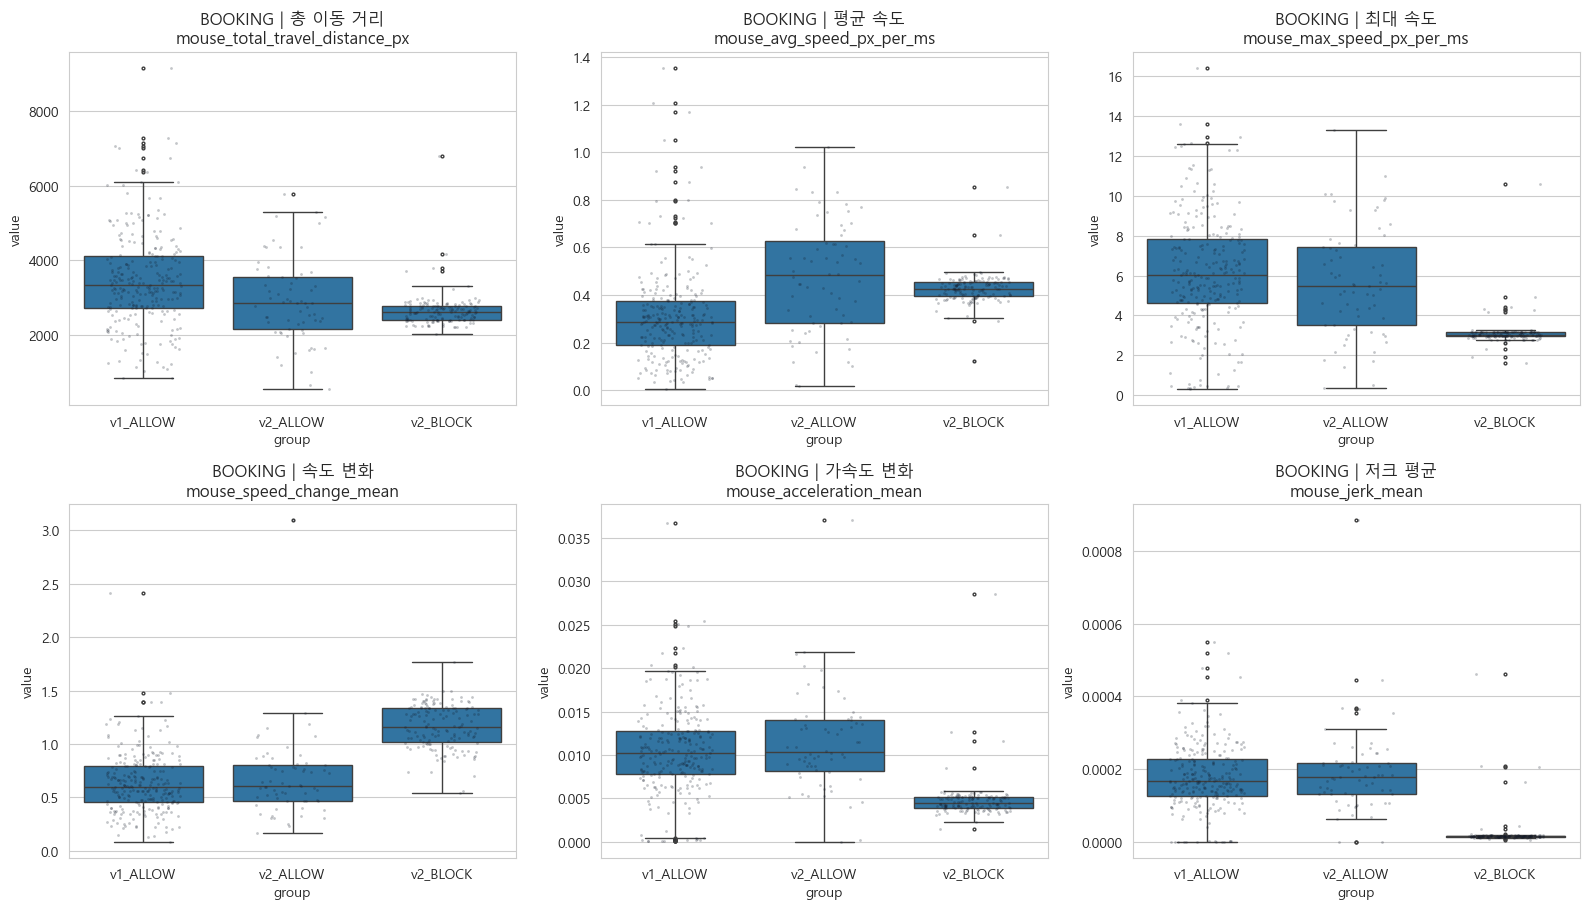

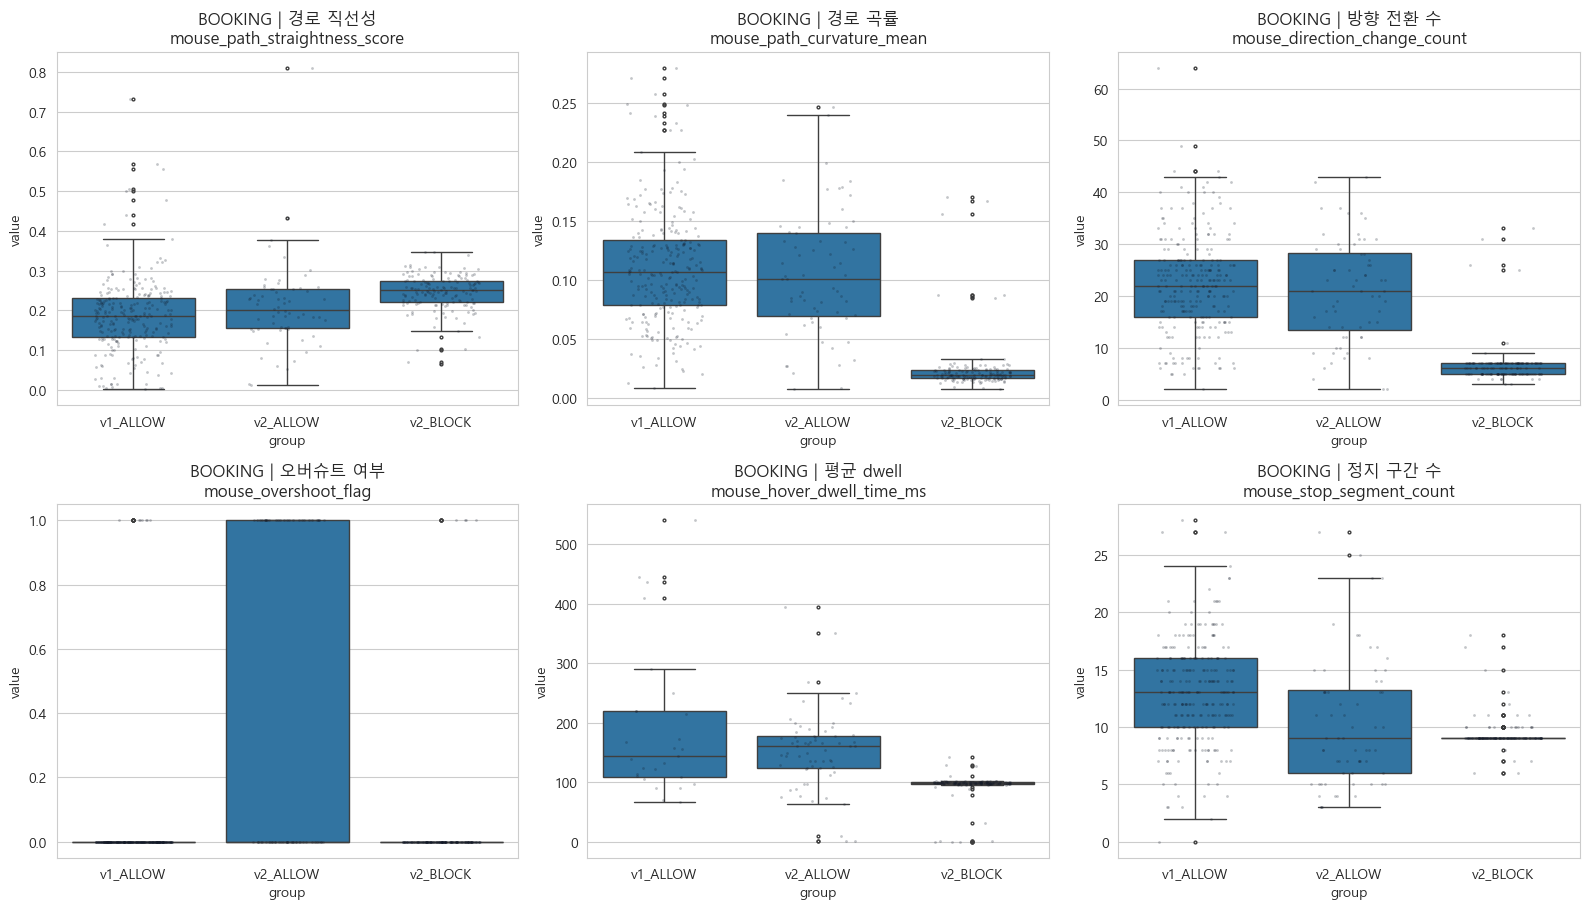

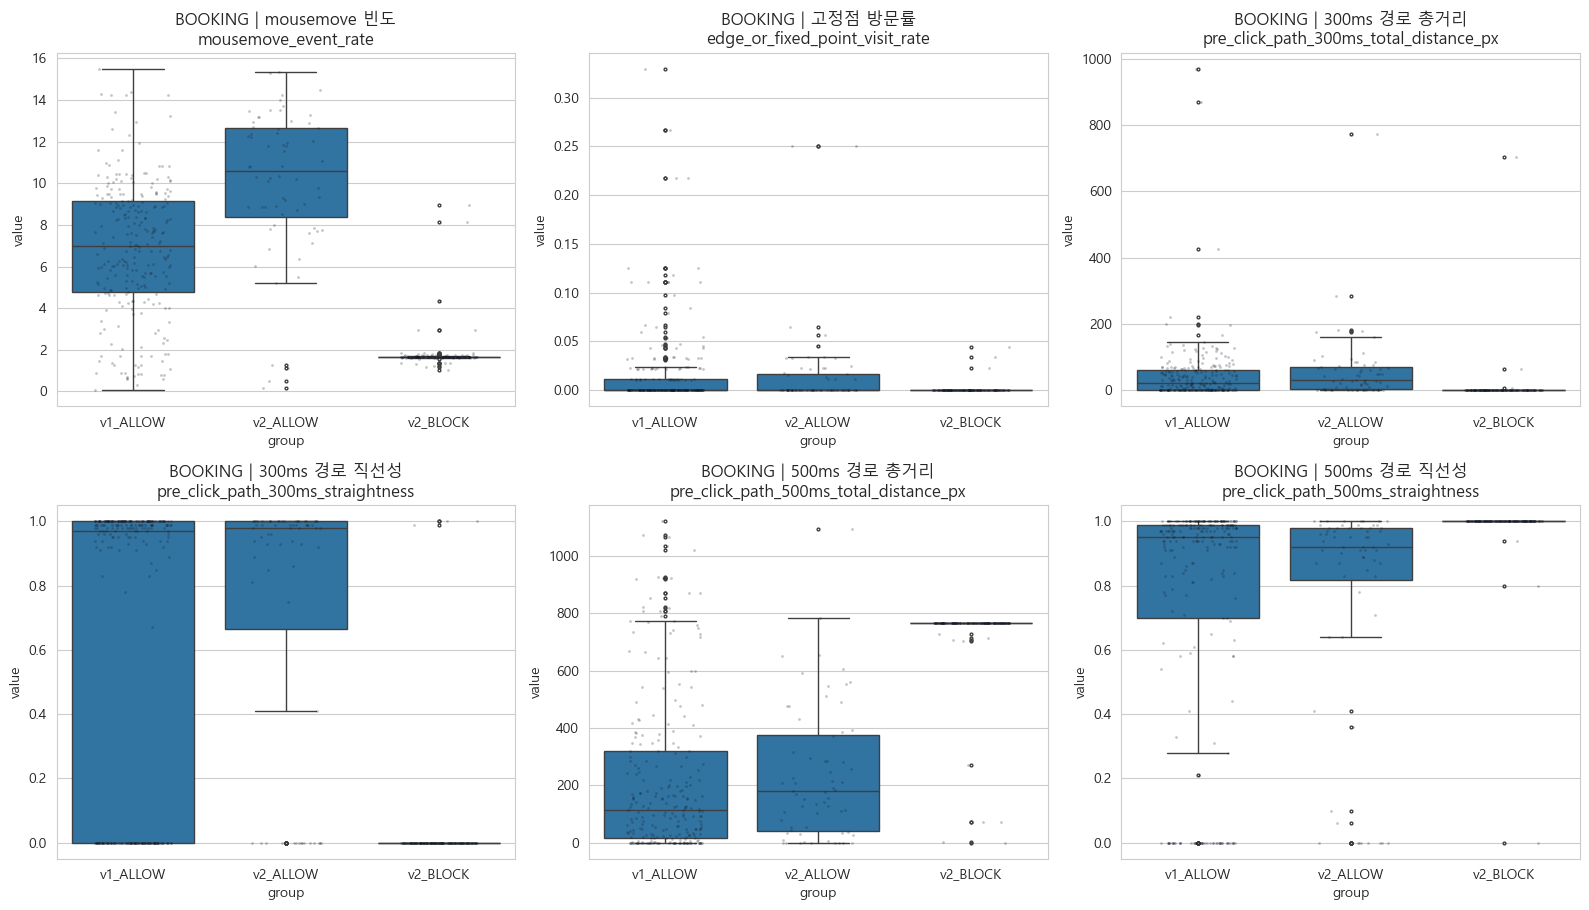

In [15]:
# type별로 boxplot을 그릴 feature 선택
# - 우선 자주 보는 feature 몇 개만 넣어두고, 필요하면 FEATURES에서 더 추가하세요.
# 모든 feature를 boxplot으로 확인 (요청 feature 전체)
KEY_FEATURES = [
    "time_to_first_click_ms",
    "time_from_element_visible_to_click_ms",
    "time_from_element_clickable_to_click_ms",
    "click_sequence_consistency_score",
    "click_position_repeat_rate",
    "double_click_rate",
    "misclick_rate",
    "reclick_rate",
    "pre_click_mousemove_count",
    "pre_click_hover_time_ms",
    "pre_click_scroll_flag",
    "immediate_post_render_click_rate",
    "mouse_total_travel_distance_px",
    "mouse_avg_speed_px_per_ms",
    "mouse_max_speed_px_per_ms",
    "mouse_speed_change_mean",
    "mouse_acceleration_mean",
    "mouse_jerk_mean",
    "mouse_path_straightness_score",
    "mouse_path_curvature_mean",
    "mouse_direction_change_count",
    "mouse_overshoot_flag",
    "mouse_hover_dwell_time_ms",
    "mouse_stop_segment_count",
    "mousemove_event_rate",
    "edge_or_fixed_point_visit_rate",
    "pre_click_path_300ms_total_distance_px",
    "pre_click_path_300ms_straightness",
    "pre_click_path_500ms_total_distance_px",
    "pre_click_path_500ms_straightness",
]

# 높은 SMD feature는 title을 주황색으로 표시 (HIGH_SMD_UNION_BY_TYPE 사용)
for t in TYPES:
    highlight = HIGH_SMD_UNION_BY_TYPE.get(t, set()) if "HIGH_SMD_UNION_BY_TYPE" in globals() else set()
    draw_boxplot_by_type(t, KEY_FEATURES, highlight=highlight)


### 3-2 PCA 시각화 (TYPE별)

- median impute → 표준화 → PCA 2D
- 그룹(v1_ALLOW/v2_ALLOW/v2_BLOCK) 분리가 되는지 빠르게 확인


PCA features (<=30% missing): 15


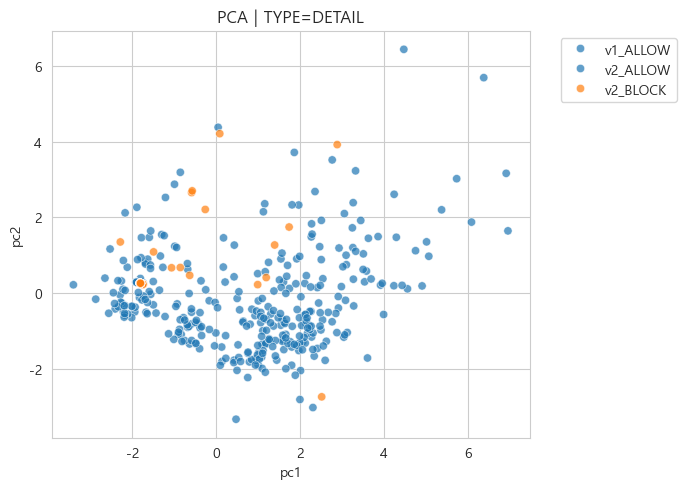

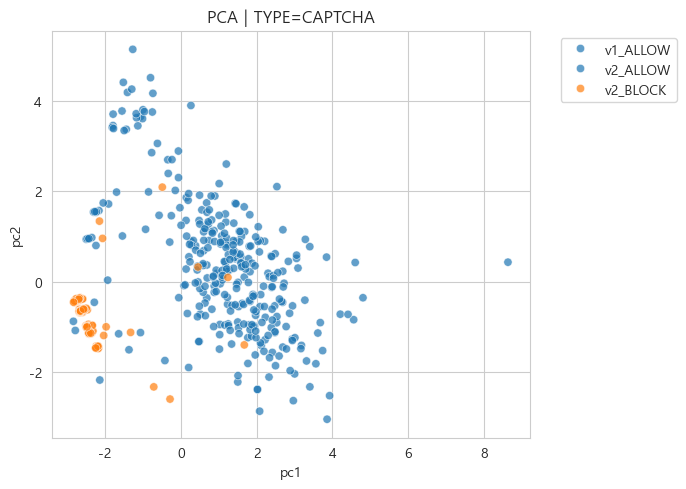

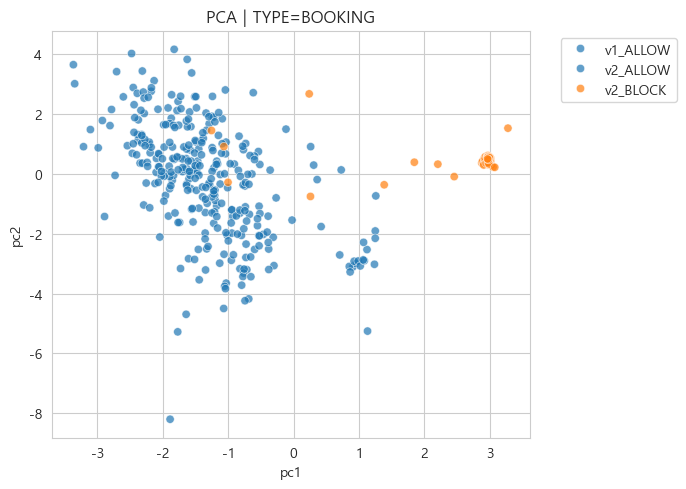

In [18]:
def pca_plot_by_type(type_name: str, *, features: List[str]) -> None:
    sub = df[df["type"] == type_name].copy()
    sub = sub[sub["group"].isin(["v1_ALLOW", "v2_ALLOW", "v2_BLOCK"])].copy()
    if sub.empty:
        print("skip empty:", type_name)
        return

    X = sub[features].apply(pd.to_numeric, errors="coerce")
    pipe_imputer = SimpleImputer(strategy="median")
    pipe_scaler = StandardScaler()
    pipe_pca = PCA(n_components=2, random_state=42)

    X_imp = pipe_imputer.fit_transform(X)
    X_scaled = pipe_scaler.fit_transform(X_imp)
    X_pca = pipe_pca.fit_transform(X_scaled)

    plot_df = pd.DataFrame({
        "pc1": X_pca[:, 0],
        "pc2": X_pca[:, 1],
        "group": sub["group"].values,
    })

    palette = {
        "v1_ALLOW": "#1f77b4",
        "v2_ALLOW": "#1f77b4",
        "v2_BLOCK": "#ff7f0e",
    }

    plt.figure(figsize=(7, 5))
    sns.scatterplot(
        data=plot_df,
        x="pc1",
        y="pc2",
        hue="group",
        palette=palette,
        alpha=0.7,
    )
    plt.title(f"PCA | TYPE={type_name}")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()


mr = df[feature_cols].isna().mean().sort_values()
pca_features = [c for c in mr.index.tolist() if mr[c] <= 0.30][:15]
print("PCA features (<=30% missing):", len(pca_features))
pca_features

for t in TYPES:
    pca_plot_by_type(t, features=pca_features)
